# deep-devops — local traces dashboard (M1)

Reads `~/.deep_devops/traces.jsonl` and produces metrics + plots without sending data anywhere.

**Confidentiality.** Each trace record stores only redacted *entity types* (e.g. `["EMAIL","ES_NIF"]`), the redacted-text SHA-256 prefix, prompt length, routing decision, latency, and tier. No raw user content. The file lives on this machine only.

**Pipeline:** Cap 10 (Huyen) p.469 — TTFT, total latency, route decision, PII flag are the M1-recordable signals. TTFT/TPOT are placeholders (0) until streaming is instrumented (M3).

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TRACE_PATH = Path.home() / ".deep_devops" / "traces.jsonl"


def load_traces(path: Path = TRACE_PATH) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    df = pd.DataFrame(rows)
    if "ts_start" in df.columns:
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True)
    return df


df = load_traces()
print(f"Loaded {len(df)} traces from {TRACE_PATH}")
df.head()

Loaded 18 traces from /home/blackview/.deep_devops/traces.jsonl


,trace_id,span_id,ts_start,model_id,provider,tier,route_decision,escalated_from,classifier_reason,pii_clean,...,ttft_ms,tpot_ms,total_latency_ms,cost_usd,prompt_hash,tool_calls,escalation_signal,intended_tier,redacted_fields_count,prompt_chars
0,d872b3a4-f9eb-4c99-be50-afe08f834f0f,f50df6ea-7d4f-46fe-a798-c79ed5587a93,2026-05-15 06:54:46.253830+00:00,deepseek-chat,deepseek_native,1,public,None,public_markers_present,True,...,0,0,1384.3,0.0,,[],None,NaN,NaN,NaN
1,814617ec-bfc9-4a36-957e-90011a4902af,62e9cf15-4078-459a-8457-ced052a539b1,2026-05-15 06:56:16.321734+00:00,deepseek-chat,deepseek_native,1,public,None,public_markers_present,True,...,0,0,1634.5,0.0,,[],None,NaN,NaN,NaN
2,5893b200-1d54-475c-bbe5-1c389f221818,9d68f08a-1d97-4a04-af01-4b859f786d96,2026-05-15 06:57:30.819357+00:00,tier2_stub,nebius,2,internal,None,soft_pii_detected_redacted,False,...,0,0,0.0,0.0,,[],None,NaN,NaN,NaN
3,fec77548-9c92-4982-ba0c-7dc2e3198c1a,c3529ec8-7342-4813-bc4f-e3d048814934,2026-05-15 07:10:25.374050+00:00,deepseek-chat,deepseek_native,1,public,None,public_markers_present,True,...,0,0,1551.0,0.0,,[],None,1.0,NaN,NaN
4,10a6e58d-9bc2-4fbc-8ae1-b0c114ba73d2,476b6ddc-28b6-4da0-9861-c7e10ddc9619,2026-05-15 07:10:40.543158+00:00,deepseek-chat,deepseek_native,1,internal_redacted,None,pii_redacted:EMAIL,False,...,0,0,3757.4,0.0,,[],None,2.0,NaN,NaN


## 1. Summary

In [2]:
if df.empty:
    print("No traces yet. Run the agent (`uv run dd`) to populate ~/.deep_devops/traces.jsonl.")
else:
    span = df["ts_start"].agg(["min", "max"])
    print(f"Time range: {span['min']}  →  {span['max']}")
    print(f"Total calls: {len(df)}")
    print(f"Unique trace_ids: {df['trace_id'].nunique()}")
    print()
    print("Tier distribution:")
    print(df["tier"].value_counts().rename_axis("tier").reset_index(name="n").to_string(index=False))
    print()
    print("Route decision distribution:")
    print(df["route_decision"].value_counts().rename_axis("route").reset_index(name="n").to_string(index=False))
    print()
    print(f"% pii_clean: {df['pii_clean'].mean() * 100:.1f}%")

Time range: 2026-05-15 06:54:46.253830+00:00  →  2026-05-15 09:05:05.607915+00:00
Total calls: 18
Unique trace_ids: 18

Tier distribution:
 tier  n
    1 17
    2  1

Route decision distribution:
            route  n
internal_redacted 11
           public  6
         internal  1

% pii_clean: 33.3%


## 2. Routing — where do queries go?

Cap 10 Table 10-1: the routing decision is itself a quality signal — drift in the proportion of *internal_redacted* vs *public* is information about how users are using the system.

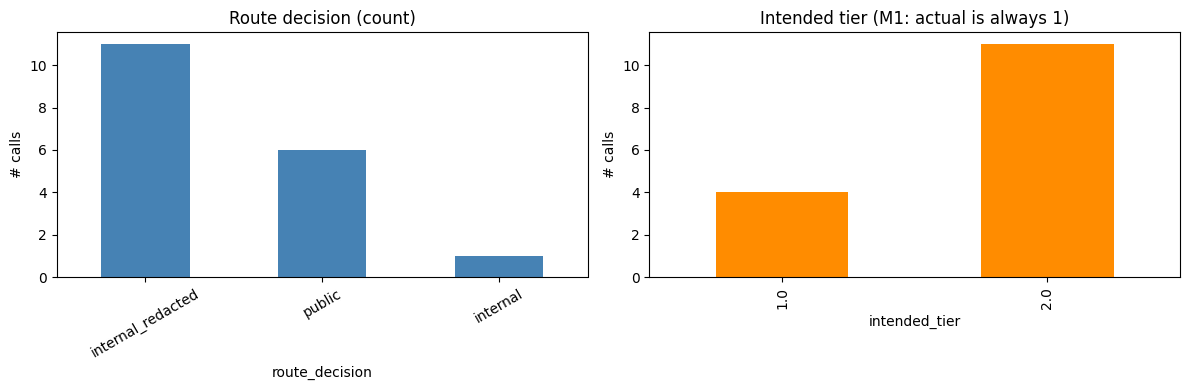

In [3]:
if not df.empty:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    df["route_decision"].value_counts().plot.bar(ax=ax[0], color="steelblue")
    ax[0].set_title("Route decision (count)")
    ax[0].set_ylabel("# calls")
    ax[0].tick_params(axis="x", rotation=30)

    intended = df["intended_tier"] if "intended_tier" in df.columns else df["tier"]
    intended.value_counts().sort_index().plot.bar(ax=ax[1], color="darkorange")
    ax[1].set_title("Intended tier (M1: actual is always 1)")
    ax[1].set_ylabel("# calls")
    plt.tight_layout()
    plt.show()

## 3. PII / redaction profile

Which entity types are being redacted most? This tells us where the scanner is earning its keep and where users keep pasting sensitive data.

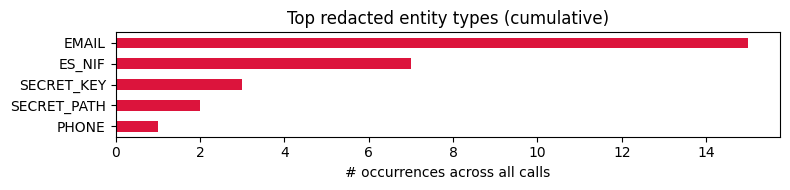


Total PII detection events: 28
Calls with at least one PII: 12 / 18


In [4]:
if not df.empty:
    all_types = Counter()
    for row in df["redacted_fields"]:
        if isinstance(row, list):
            all_types.update(row)

    if not all_types:
        print("No PII redacted in any trace so far.")
    else:
        top = pd.Series(all_types).sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(8, max(2, 0.4 * len(top))))
        top.plot.barh(ax=ax, color="crimson")
        ax.set_title("Top redacted entity types (cumulative)")
        ax.set_xlabel("# occurrences across all calls")
        plt.tight_layout()
        plt.show()

        print(f"\nTotal PII detection events: {sum(all_types.values())}")
        print(f"Calls with at least one PII: {(~df['pii_clean']).sum()} / {len(df)}")

## 4. Latency

Cap 9 p.469: `total_latency_ms` is the user-visible metric. `ttft_ms` / `tpot_ms` are 0 in M1 (streaming not instrumented for trace yet).

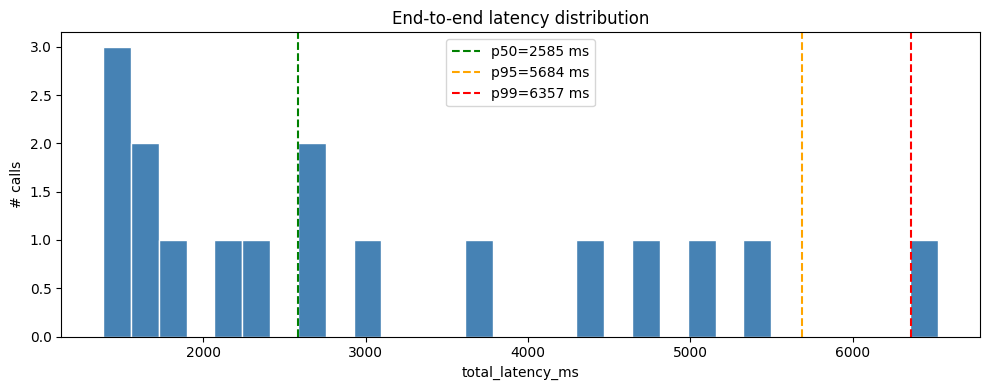

n=17  mean=3074 ms  p50=2585  p95=5684  p99=6357


In [5]:
if not df.empty and df["total_latency_ms"].sum() > 0:
    lat = df[df["total_latency_ms"] > 0]["total_latency_ms"]
    p50, p95, p99 = np.percentile(lat, [50, 95, 99])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(lat, bins=30, color="steelblue", edgecolor="white")
    for p, label, color in [(p50, "p50", "green"), (p95, "p95", "orange"), (p99, "p99", "red")]:
        ax.axvline(p, color=color, linestyle="--", label=f"{label}={p:.0f} ms")
    ax.set_xlabel("total_latency_ms")
    ax.set_ylabel("# calls")
    ax.set_title("End-to-end latency distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"n={len(lat)}  mean={lat.mean():.0f} ms  p50={p50:.0f}  p95={p95:.0f}  p99={p99:.0f}")
else:
    print("No latency data yet.")

## 5. Latency vs prompt size

Only meaningful with the M1.5 trace upgrade (`prompt_chars`). Older traces are skipped.

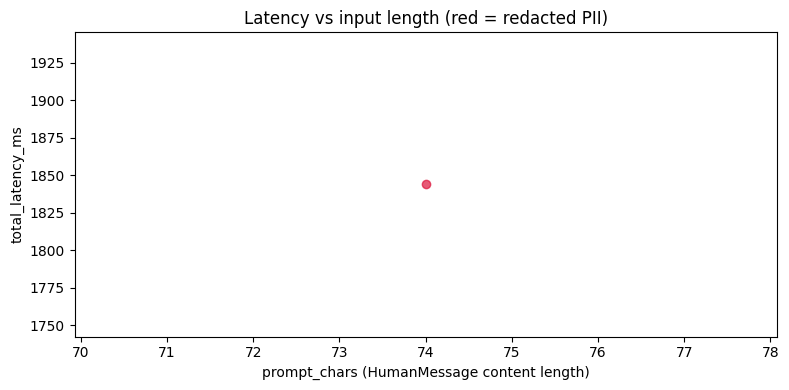

In [6]:
if not df.empty and "prompt_chars" in df.columns:
    sub = df[(df["prompt_chars"] > 0) & (df["total_latency_ms"] > 0)]
    if not sub.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        colors = sub["pii_clean"].map({True: "steelblue", False: "crimson"})
        ax.scatter(sub["prompt_chars"], sub["total_latency_ms"], c=colors, alpha=0.7)
        ax.set_xlabel("prompt_chars (HumanMessage content length)")
        ax.set_ylabel("total_latency_ms")
        ax.set_title("Latency vs input length (red = redacted PII)")
        plt.tight_layout()
        plt.show()
    else:
        print("No traces with both prompt_chars and latency yet.")
else:
    print("`prompt_chars` not present — older traces. Run the agent again to record it.")

## 6. Health checks

Invariants that should never fire. If any of these has rows, there is a router bug.

In [7]:
if not df.empty:
    checks = {}
    has_scan_error = "scan_error" in df.columns
    err_mask = df["scan_error"] == True if has_scan_error else pd.Series([False] * len(df), index=df.index)

    # 1. PII detected but no fields recorded — exclude fail-closed events, where
    #    pii_clean=false and redacted_fields=[] is by design (no scan completed).
    pii_silent = df[(~df["pii_clean"]) & (df["redacted_fields"].apply(lambda x: not x)) & (~err_mask)]
    checks["pii detected but no fields recorded"] = len(pii_silent)

    # 2. Latency > 30s — hung call or local clock skew.
    slow = df[df["total_latency_ms"] > 30_000]
    checks["latency > 30s"] = len(slow)

    # 3. intended_tier mismatch — expected to be non-zero while only tier 1 is
    #    implemented; will tighten once tier 2/3 are wired.
    if "intended_tier" in df.columns:
        mismatch = df[df["intended_tier"] != df["tier"]]
        checks["intended_tier != actual_tier (expected non-zero in M1)"] = len(mismatch)

    # 4. Fail-closed events (M1.5): scanner raised and router aborted before any
    #    upstream call. Any occurrence is a bug — investigate the input or a regression.
    if has_scan_error:
        checks["scan_error (fail-closed fired)"] = int(err_mask.sum())

    print("Health-check signals:")
    for k, v in checks.items():
        flag = "⚠️" if v > 0 and "expected" not in k else "✓"
        print(f"  {flag}  {k}: {v}")

Health-check signals:
  ✓  pii detected but no fields recorded: 0
  ✓  latency > 30s: 0
  ✓  intended_tier != actual_tier (expected non-zero in M1): 14


## 7. Confidentiality audit — what does the file actually contain?

Sanity check: print a few raw records and confirm there is no user content, no entity values, no API keys.

In [8]:
if not df.empty:
    sample = df.tail(3).to_dict("records")
    for rec in sample:
        print(json.dumps(rec, default=str, indent=2))
        print("-" * 60)

{
  "trace_id": "af384f16-b6a7-4aa8-8c90-281805feb2f4",
  "span_id": "5376d100-7b88-4565-9b11-bb4e3b84bf86",
  "ts_start": "2026-05-15 08:48:47.998830+00:00",
  "model_id": "deepseek-chat",
  "provider": "deepseek_native",
  "tier": 1,
  "route_decision": "public",
  "escalated_from": null,
  "classifier_reason": "public_markers_present",
  "pii_clean": true,
  "redacted_fields": [],
  "input_tokens": 0,
  "output_tokens": 0,
  "cached_input_tokens": 0,
  "ttft_ms": 0,
  "tpot_ms": 0,
  "total_latency_ms": 1511.7,
  "cost_usd": 0.0,
  "prompt_hash": "",
  "tool_calls": [],
  "escalation_signal": null,
  "intended_tier": 1.0,
  "redacted_fields_count": NaN,
  "prompt_chars": NaN
}
------------------------------------------------------------
{
  "trace_id": "bbe69caa-0b0b-4e1f-86db-30188dca63a2",
  "span_id": "448a39f7-cb35-480d-b688-90e3cc7f58c5",
  "ts_start": "2026-05-15 08:57:46.453320+00:00",
  "model_id": "deepseek-chat",
  "provider": "deepseek_native",
  "tier": 1,
  "route_decis